In [20]:
import numpy as np
import pandas as pd

import seaborn as sns

import ucimlrepo as uciml

from collections import Counter

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, make_scorer, accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import GridSearchCV, train_test_split

pd.set_option('display.max_columns', None)


In [3]:
uciml.list_available_datasets()

-------------------------------------
The following datasets are available:
-------------------------------------
Dataset Name                                                                            ID    
------------                                                                            --    
Abalone                                                                                 1     
Adult                                                                                   2     
Annealing                                                                               3     
Audiology (Standardized)                                                                8     
Auto MPG                                                                                9     
Automobile                                                                              10    
Balance Scale                                                                           12    
Balloons                       

In [4]:
wine = uciml.fetch_ucirepo(id=109)
print(type(wine))
print(wine.keys())



<class 'ucimlrepo.dotdict.dotdict'>
dict_keys(['data', 'metadata', 'variables'])


In [5]:
wine['metadata']

{'uci_id': 109,
 'name': 'Wine',
 'repository_url': 'https://archive.ics.uci.edu/dataset/109/wine',
 'data_url': 'https://archive.ics.uci.edu/static/public/109/data.csv',
 'abstract': 'Using chemical analysis to determine the origin of wines',
 'area': 'Physics and Chemistry',
 'tasks': ['Classification'],
 'characteristics': ['Tabular'],
 'num_instances': 178,
 'num_features': 13,
 'feature_types': ['Integer', 'Real'],
 'demographics': [],
 'target_col': ['class'],
 'index_col': None,
 'has_missing_values': 'no',
 'missing_values_symbol': None,
 'year_of_dataset_creation': 1992,
 'last_updated': 'Mon Aug 28 2023',
 'dataset_doi': '10.24432/C5PC7J',
 'creators': ['Stefan Aeberhard', 'M. Forina'],
 'intro_paper': {'ID': 246,
  'type': 'NATIVE',
  'title': 'Comparative analysis of statistical pattern recognition methods in high dimensional settings',
  'authors': 'S. Aeberhard, D. Coomans, O. Vel',
  'venue': 'Pattern Recognition',
  'year': 1994,
  'journal': None,
  'DOI': '10.1016/003

In [6]:
print(type(wine['variables']))
wine['variables']

<class 'pandas.core.frame.DataFrame'>


,name,role,type,demographic,description,units,missing_values
0,class,Target,Categorical,None,None,None,no
1,Alcohol,Feature,Continuous,None,None,None,no
2,Malicacid,Feature,Continuous,None,None,None,no
3,Ash,Feature,Continuous,None,None,None,no
4,Alcalinity_of_ash,Feature,Continuous,None,None,None,no
5,Magnesium,Feature,Integer,None,None,None,no
6,Total_phenols,Feature,Continuous,None,None,None,no
7,Flavanoids,Feature,Continuous,None,None,None,no
8,Nonflavanoid_phenols,Feature,Continuous,None,None,None,no
9,Proanthocyanins,Feature,Continuous,None,None,None,no


In [7]:
print(type(wine['data']))
print(wine['data'].keys())

original = wine['data']['original']
X = wine['data']['features']
y = wine['data']['targets']

display(original)


<class 'ucimlrepo.dotdict.dotdict'>
dict_keys(['ids', 'features', 'targets', 'original', 'headers'])


,Alcohol,Malicacid,Ash,Alcalinity_of_ash,Magnesium,Total_phenols,Flavanoids,Nonflavanoid_phenols,Proanthocyanins,Color_intensity,Hue,0D280_0D315_of_diluted_wines,Proline,class
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,1
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,1
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,1
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,1
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740,3
174,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750,3
175,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835,3
176,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840,3


In [65]:
# Count the number of classes
y.value_counts(sort=False)



class
1        59
2        71
3        48
Name: count, dtype: int64

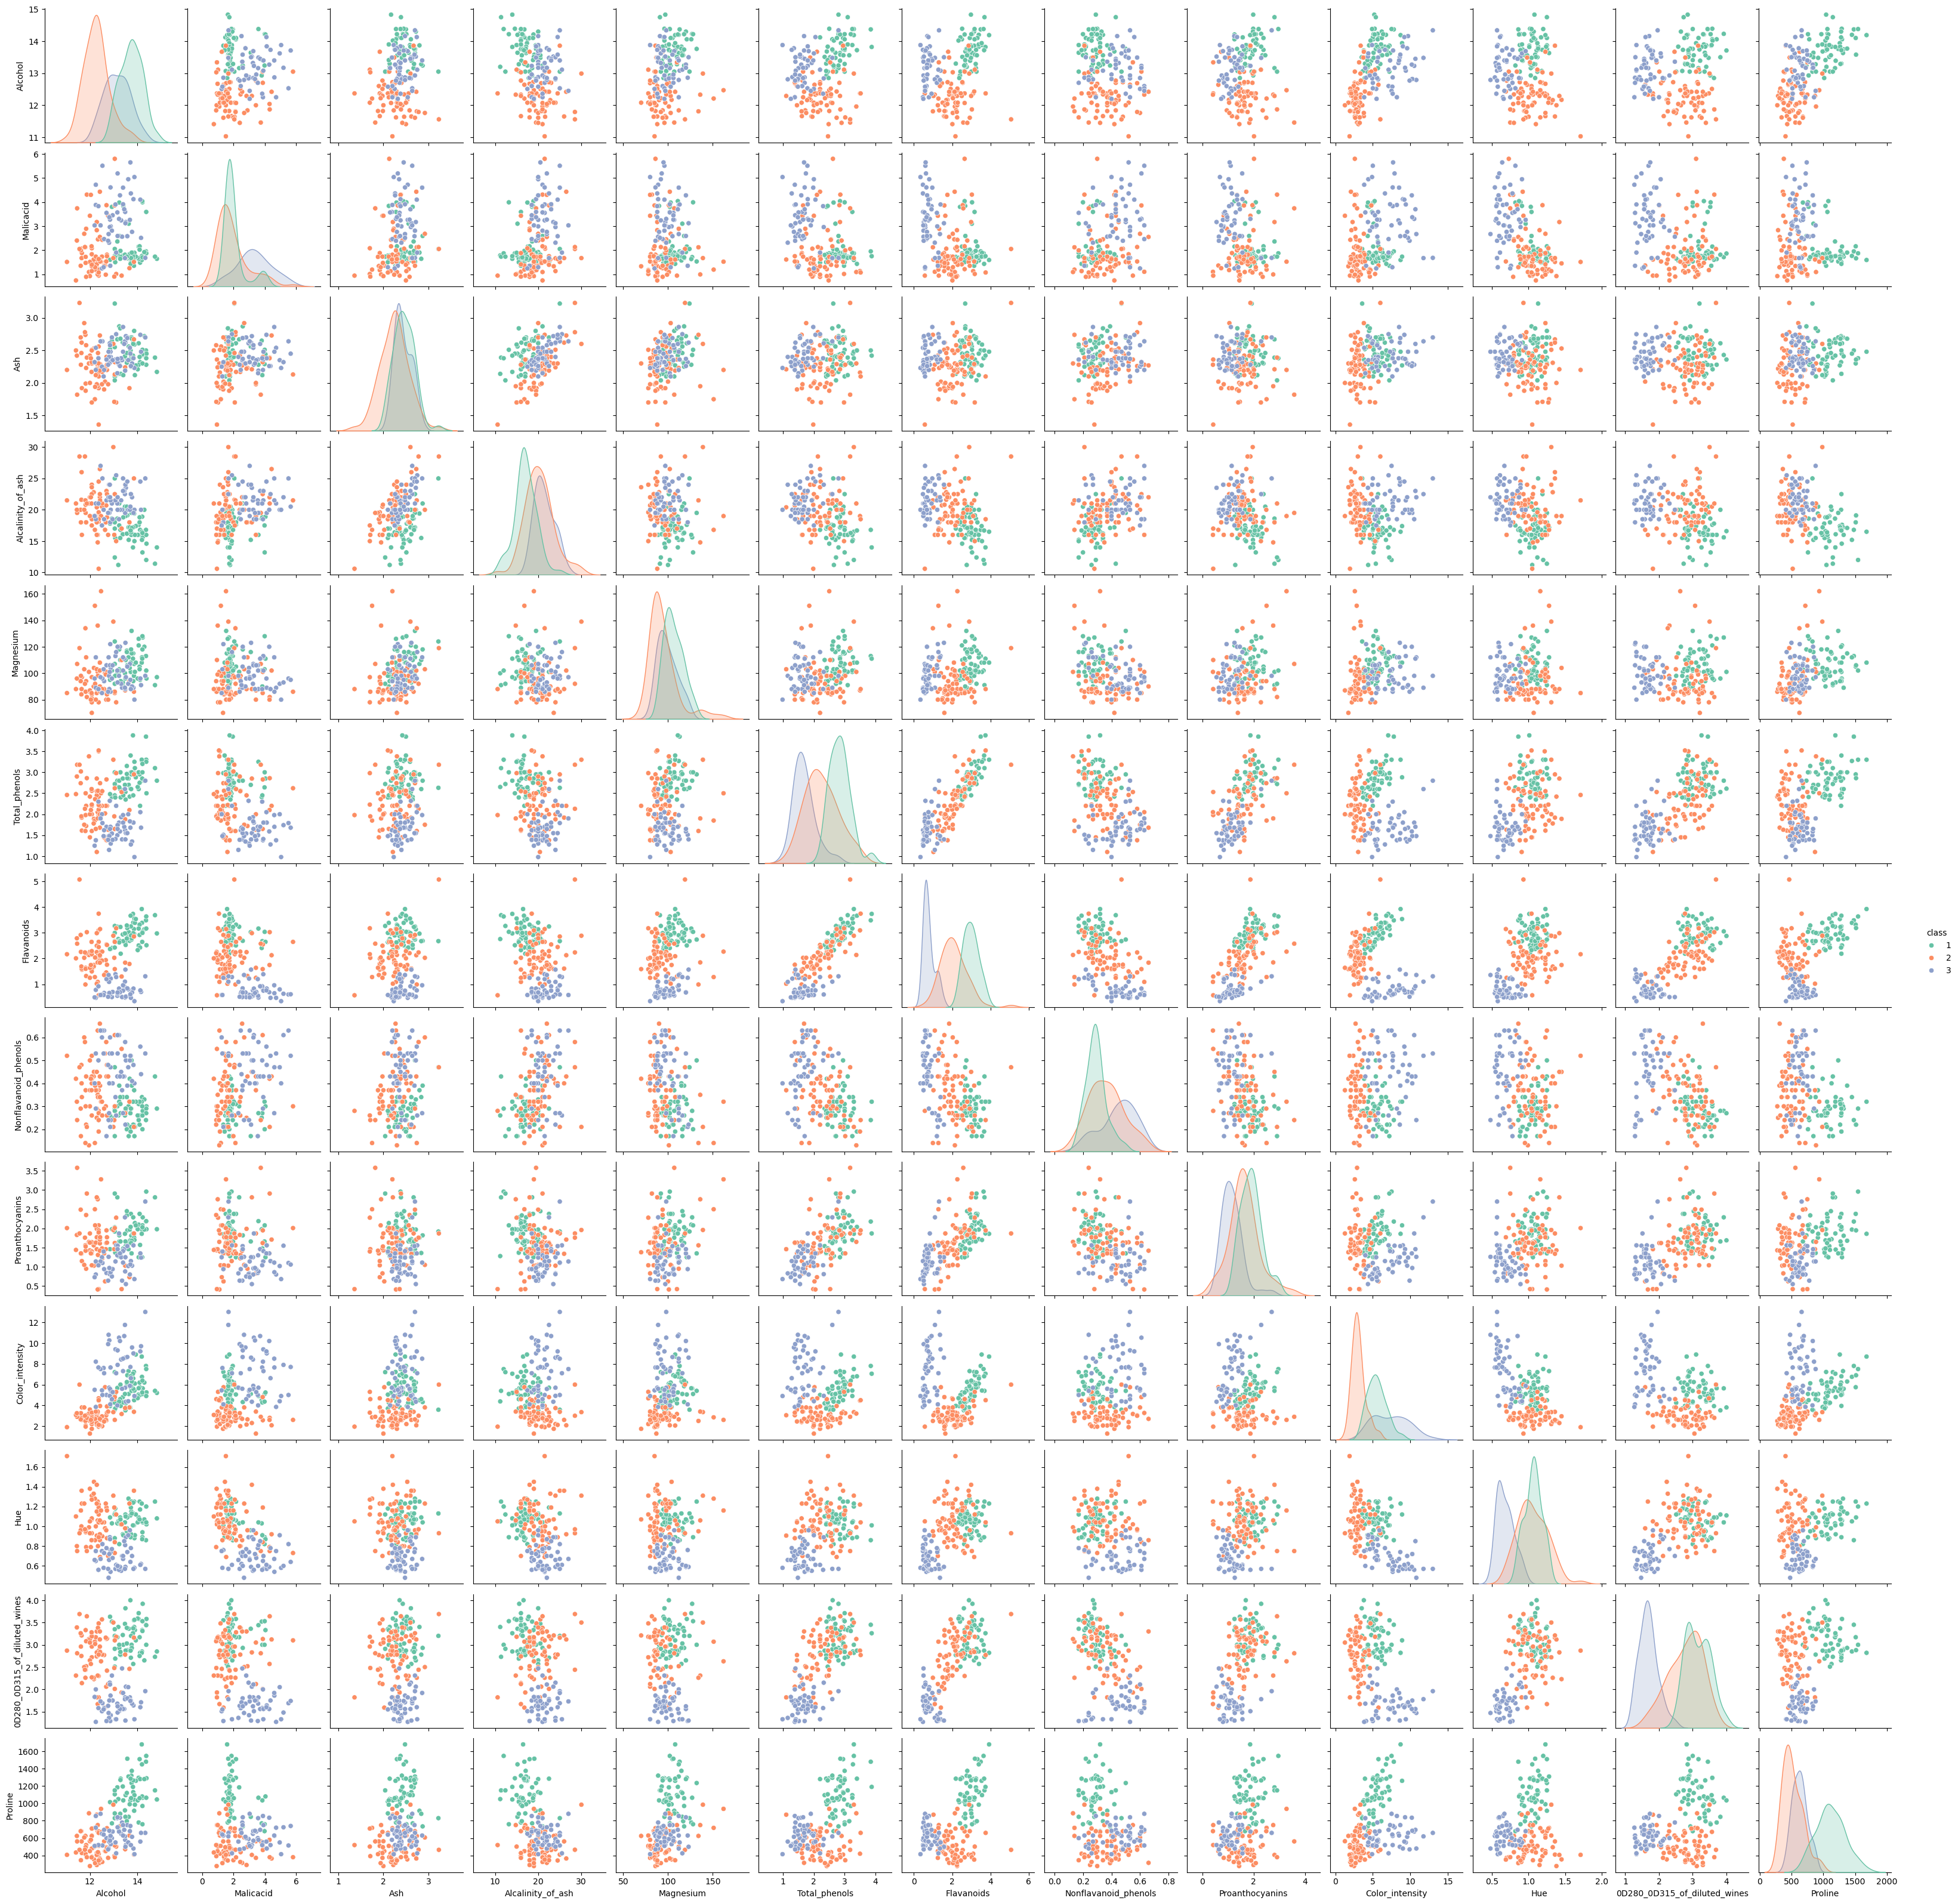

In [8]:
# Make a pairplot of the features and the target
sns.pairplot(original, hue='class', palette='Set2')

<Axes: >

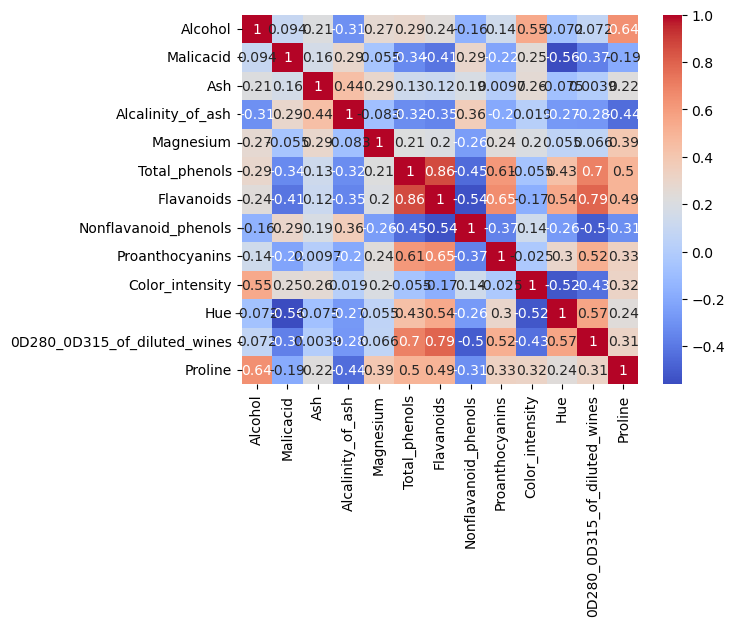

In [71]:
# Make a heatmap of the correlation matrix of the features
corr_matrix = X.corr()
corr_matrix

# plot the correlation matrix
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')


# plot the histogram of the features
#wine.hist(figsize=(12, 8))


In [14]:
display(X)
display(y)

X_subset = X[['Proline', 'Color_intensity', 'Hue', '0D280_0D315_of_diluted_wines']].copy()
y = y.copy()

display(X_subset)


,Alcohol,Malicacid,Ash,Alcalinity_of_ash,Magnesium,Total_phenols,Flavanoids,Nonflavanoid_phenols,Proanthocyanins,Color_intensity,Hue,0D280_0D315_of_diluted_wines,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740
174,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750
175,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835
176,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840


,class
0,1
1,1
2,1
3,1
4,1
...,...
173,3
174,3
175,3
176,3


,Proline,Color_intensity,Hue,0D280_0D315_of_diluted_wines
0,1065,5.64,1.04,3.92
1,1050,4.38,1.05,3.40
2,1185,5.68,1.03,3.17
3,1480,7.80,0.86,3.45
4,735,4.32,1.04,2.93
...,...,...,...,...
173,740,7.70,0.64,1.74
174,750,7.30,0.70,1.56
175,835,10.20,0.59,1.56
176,840,9.30,0.60,1.62


In [16]:
y = np.ravel(y)
print(y.shape)

(178,)


In [17]:
X_train, X_test, y_train, y_test = train_test_split(X_subset, y, test_size=0.1, random_state=42, shuffle=True)
display(X_train)
display(y_train)

# Create a pipeline with standard scaling and logistic regression
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logistic_regression', LogisticRegression(class_weight='balanced'))
])

# Define the parameter grid
param_grid = {
    #'logistic_regression__alpha': [0.01, 0.1, 1, 10]
    'logistic_regression__penalty': ['l2']
}

# Define the scoring metrics
#roc_auc = make_scorer(roc_auc_score,multi_class='ovr')
accuracy = make_scorer(accuracy_score)
precision = make_scorer(precision_score, average='macro')
recall = make_scorer(recall_score, average='macro')
f1 = make_scorer(f1_score, average='macro')

scores = {
    #'roc_auc': roc_auc,
    'accuracy': accuracy,
    'precision': precision,
    'recall': recall,
    'f1': f1
}

# Perform grid search with cross-validation
grid_search = GridSearchCV(pipeline, param_grid, cv=10, scoring=scores, refit='accuracy')

,Proline,Color_intensity,Hue,0D280_0D315_of_diluted_wines
9,1045,7.22,1.01,3.55
114,385,2.90,0.93,3.19
18,1680,8.70,1.23,2.82
66,502,5.30,1.12,3.18
60,680,3.27,1.25,1.67
...,...,...,...,...
71,410,3.38,1.36,3.16
106,510,3.40,1.00,3.17
14,1547,7.50,1.20,3.00
92,495,3.05,0.96,2.06


array([1, 2, 1, 2, 2, 3, 3, 3, 2, 2, 2, 1, 1, 2, 3, 1, 1, 1, 3, 3, 2, 3,
       1, 2, 2, 2, 3, 1, 2, 2, 3, 1, 2, 1, 1, 3, 3, 2, 2, 1, 2, 1, 3, 2,
       2, 3, 1, 1, 1, 3, 1, 1, 2, 3, 2, 1, 3, 2, 1, 3, 2, 2, 1, 2, 1, 1,
       2, 1, 1, 3, 2, 2, 2, 1, 2, 2, 2, 3, 3, 1, 2, 3, 3, 2, 2, 1, 2, 3,
       3, 2, 3, 2, 2, 2, 1, 1, 3, 1, 3, 1, 1, 2, 2, 1, 1, 1, 2, 1, 2, 3,
       2, 2, 2, 3, 3, 2, 1, 1, 2, 3, 3, 1, 2, 3, 3, 3, 3, 2, 1, 2, 1, 3,
       1, 1, 2, 1, 1, 3, 2, 1, 3, 3, 1, 1, 3, 3, 3, 2, 2, 2, 2, 2, 2, 3,
       1, 2, 2, 1, 2, 2])

In [18]:
grid_search.fit(X_train, y_train)

GridSearchCV(cv=10,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('logistic_regression',
                                        LogisticRegression(class_weight='balanced'))]),
             param_grid={'logistic_regression__penalty': ['l2']},
             refit='accuracy',
             scoring={'accuracy': make_scorer(accuracy_score, response_method='predict'),
                      'f1': make_scorer(f1_score, response_method='predict', average=macro),
                      'precision': make_scorer(precision_score, response_method='predict', average=macro),
                      'recall': make_scorer(recall_score, response_method='predict', average=macro)})

In [19]:
# predict the test set with classification report
y_pred = grid_search.best_estimator_.predict(X_test)
print(classification_report(y_test, y_pred))

# Print the best parameters and the corresponding score
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best score: {grid_search.best_score_}")

              precision    recall  f1-score   support

           1       1.00      1.00      1.00         7
           2       1.00      1.00      1.00         7
           3       1.00      1.00      1.00         4

    accuracy                           1.00        18
   macro avg       1.00      1.00      1.00        18
weighted avg       1.00      1.00      1.00        18

Best parameters: {'logistic_regression__penalty': 'l2'}
Best score: 0.93125


In [197]:
pd.DataFrame(grid_search.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_logistic_regression__penalty,params,split0_test_accuracy,split1_test_accuracy,split2_test_accuracy,split3_test_accuracy,split4_test_accuracy,split5_test_accuracy,split6_test_accuracy,split7_test_accuracy,split8_test_accuracy,split9_test_accuracy,mean_test_accuracy,std_test_accuracy,rank_test_accuracy,split0_test_precision,split1_test_precision,split2_test_precision,split3_test_precision,split4_test_precision,split5_test_precision,split6_test_precision,split7_test_precision,split8_test_precision,split9_test_precision,mean_test_precision,std_test_precision,rank_test_precision,split0_test_recall,split1_test_recall,split2_test_recall,split3_test_recall,split4_test_recall,split5_test_recall,split6_test_recall,split7_test_recall,split8_test_recall,split9_test_recall,mean_test_recall,std_test_recall,rank_test_recall,split0_test_f1,split1_test_f1,split2_test_f1,split3_test_f1,split4_test_f1,split5_test_f1,split6_test_f1,split7_test_f1,split8_test_f1,split9_test_f1,mean_test_f1,std_test_f1,rank_test_f1
0,0.001918,0.000419,0.002066,0.000423,l2,{'logistic_regression__penalty': 'l2'},1.0,0.5,1.0,1.0,0.5,1.0,1.0,1.0,1.0,1.0,0.9,0.2,1,1.0,0.25,1.0,1.0,0.333333,1.0,1.0,1.0,1.0,1.0,0.858333,0.283945,1,1.0,0.5,1.0,1.0,0.333333,1.0,1.0,1.0,1.0,1.0,0.883333,0.236291,1,1.0,0.333333,1.0,1.0,0.333333,1.0,1.0,1.0,1.0,1.0,0.866667,0.266667,1
